# Analisis Pengaruh Tingkat Konsumsi Garam terhadap Risiko Hipertensi Menggunakan Algoritma Klasifikasi LightGBM berbasis SHAP

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import os
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import joblib


In [ ]:
from google.colab import files

uploaded = files.upload()

nama_file = list(uploaded.keys())[0]
print('Nama file:', nama_file)

if nama_file.endswith('.csv'):
    df = pd.read_csv(nama_file)
elif nama_file.endswith(('.xlsx', '.xls')):
    df = pd.read_excel(nama_file)

Saving hypertension_dataset.csv to hypertension_dataset (9).csv
Nama file: hypertension_dataset (9).csv


## membaca data

In [ ]:

display(df.head())

print('\nInfo Dataset:')
df.info()

print('\nStatistik Deskriptif:')
display(df.describe(include='all'))

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No



Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1985 non-null   int64  
 1   Salt_Intake       1985 non-null   float64
 2   Stress_Score      1985 non-null   int64  
 3   BP_History        1985 non-null   object 
 4   Sleep_Duration    1985 non-null   float64
 5   BMI               1985 non-null   float64
 6   Medication        1186 non-null   object 
 7   Family_History    1985 non-null   object 
 8   Exercise_Level    1985 non-null   object 
 9   Smoking_Status    1985 non-null   object 
 10  Has_Hypertension  1985 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 170.7+ KB

Statistik Deskriptif:


,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
count,1985.000000,1985.000000,1985.000000,1985,1985.000000,1985.000000,1186,1985,1985,1985,1985
unique,NaN,NaN,NaN,3,NaN,NaN,4,2,3,2,2
top,NaN,NaN,NaN,Normal,NaN,NaN,Beta Blocker,No,Low,Non-Smoker,Yes
freq,NaN,NaN,NaN,796,NaN,NaN,412,1000,936,1417,1032
mean,50.341058,8.531688,4.979345,NaN,6.452242,26.015315,NaN,NaN,NaN,NaN,NaN
std,19.442042,1.994907,3.142303,NaN,1.542207,4.512857,NaN,NaN,NaN,NaN,NaN
min,18.000000,2.500000,0.000000,NaN,1.500000,11.900000,NaN,NaN,NaN,NaN,NaN
25%,34.000000,7.200000,2.000000,NaN,5.400000,23.000000,NaN,NaN,NaN,NaN,NaN
50%,50.000000,8.500000,5.000000,NaN,6.500000,25.900000,NaN,NaN,NaN,NaN,NaN
75%,67.000000,9.900000,8.000000,NaN,7.500000,29.100000,NaN,NaN,NaN,NaN,NaN


## distribusi variabel target

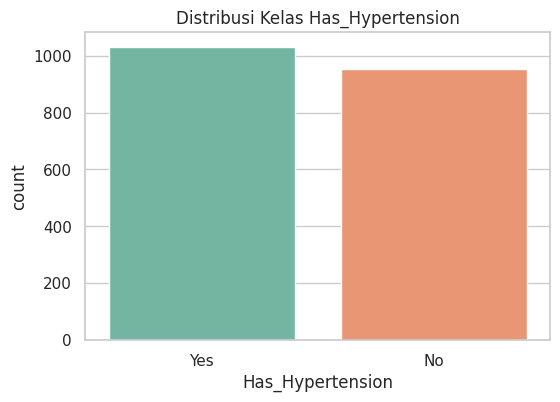

Jumlah per kelas:
Has_Hypertension
Yes    1032
No      953
Name: count, dtype: int64

Persentase per kelas:
Has_Hypertension
Yes    51.99
No     48.01
Name: proportion, dtype: float64

Rasio imbalance: 1.08 : 1


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Has_Hypertension', palette='Set2')
plt.title('Distribusi Kelas Has_Hypertension')
plt.show()

# Tambahan: hitung angka pastinya
target_counts = df['Has_Hypertension'].value_counts()
target_pct = df['Has_Hypertension'].value_counts(normalize=True) * 100

print("Jumlah per kelas:")
print(target_counts)
print("\nPersentase per kelas:")
print(target_pct.round(2))

imbalance_ratio = target_counts.max() / target_counts.min()
print(f"\nRasio imbalance: {imbalance_ratio:.2f} : 1")

## analisis numerik

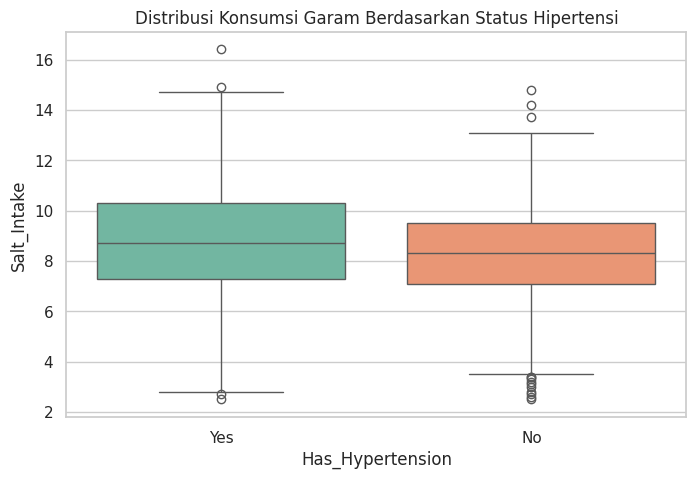

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Has_Hypertension', y='Salt_Intake', palette='Set2')
plt.title('Distribusi Konsumsi Garam Berdasarkan Status Hipertensi')
plt.show()

## cek outlier

In [ ]:
# 1. Otomatis mendefinisikan kolom numerik (atau pilih manual)
num_cols_check = df.select_dtypes(include=['number']).columns.tolist()

# 2. Jalankan kode deteksi outlier Anda
print("=== Hasil Deteksi Outlier ===\n")
for col in num_cols_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    outlier = df[
        (df[col] < batas_bawah) |
        (df[col] > batas_atas)
    ]

    pct = len(outlier) / len(df) * 100

    print(f"{col}:")
    print(f"  Batas bawah : {batas_bawah:.2f}")
    print(f"  Batas atas  : {batas_atas:.2f}")
    print(f"  Jumlah outlier: {len(outlier)} ({pct:.2f}% dari total data)\n")

=== Hasil Deteksi Outlier ===

Age:
  Batas bawah : -15.50
  Batas atas  : 116.50
  Jumlah outlier: 0 (0.00% dari total data)

Salt_Intake:
  Batas bawah : 3.15
  Batas atas  : 13.95
  Jumlah outlier: 17 (0.86% dari total data)

Stress_Score:
  Batas bawah : -7.00
  Batas atas  : 17.00
  Jumlah outlier: 0 (0.00% dari total data)

Sleep_Duration:
  Batas bawah : 2.25
  Batas atas  : 10.65
  Jumlah outlier: 12 (0.60% dari total data)

BMI:
  Batas bawah : 13.85
  Batas atas  : 38.25
  Jumlah outlier: 16 (0.81% dari total data)



## korelasi antar variabel numerik

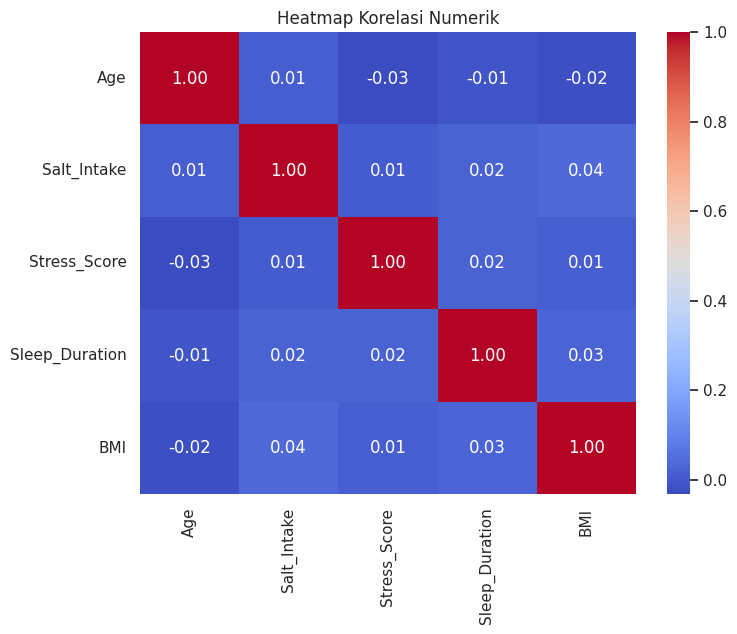

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Numerik')
plt.show()

## fitur kategorial

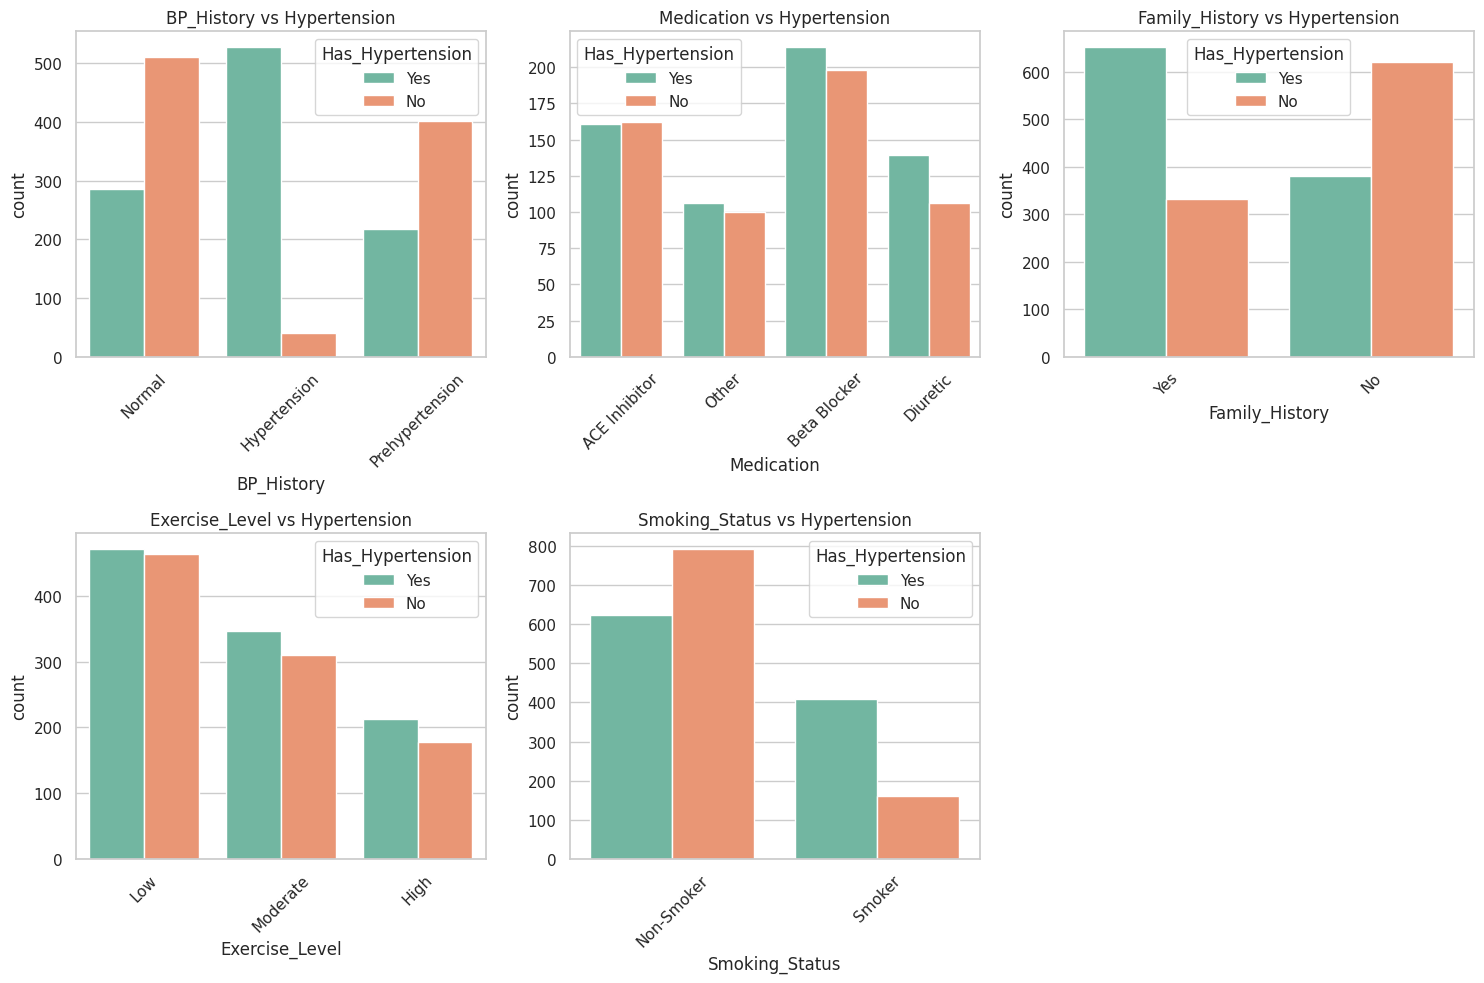

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns.drop('Has_Hypertension')
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df, x=col, hue='Has_Hypertension', palette='Set2')
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Hypertension')
plt.tight_layout()
plt.show()

##  PLOT LENGKAP: AGREGASI, & ACUAN INDIKASI

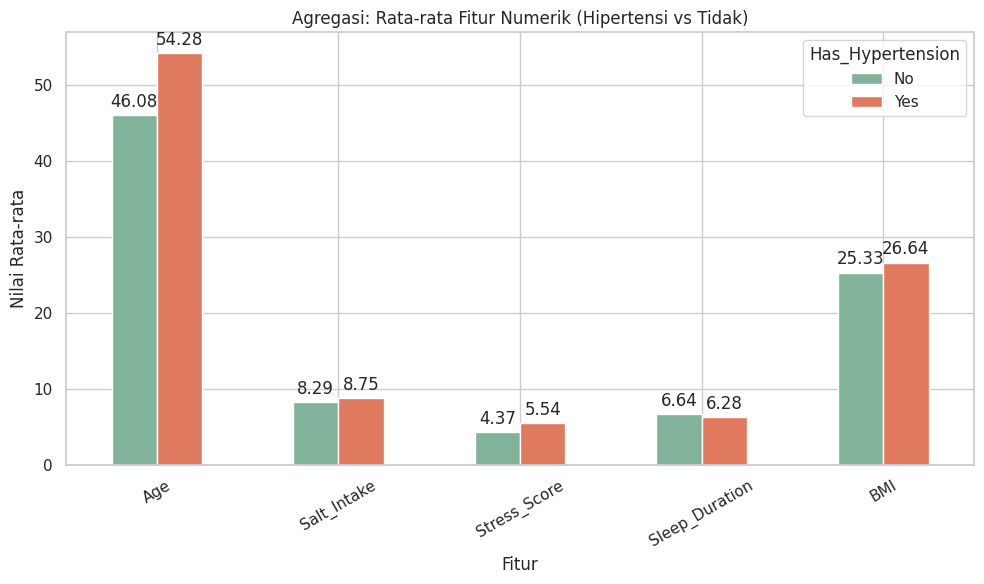


Tabel Acuan Indikasi Hipertensi (Semua Fitur/Kategori):


,Label,Nilai (%),Status,Kekuatan Indikasi
0,BP_History: Hypertension,92.794376,Terindikasi,42.8
1,Stress_Score > 4.96,23.714772,Terindikasi,23.7
2,Smoking_Status: Smoker,71.830986,Terindikasi,21.8
3,Age > 50.18,16.334692,Terindikasi,16.3
4,Family_History: Yes,66.192893,Terindikasi,16.2
5,BP_History: Prehypertension,35.161290,Tidak Terindikasi,14.8
6,BP_History: Normal,35.929648,Tidak Terindikasi,14.1
7,Family_History: No,38.000000,Tidak Terindikasi,12.0
8,Medication: Diuretic,56.734694,Terindikasi,6.7
9,Smoking_Status: Non-Smoker,44.036697,Tidak Terindikasi,6.0


In [ ]:

# ---------- PLOT 3: Agregasi Rata-rata Fitur Numerik (Yes vs No) ----------
agg_numeric = df.groupby('Has_Hypertension')[numerical_cols].mean().T

fig, ax = plt.subplots(figsize=(10, 6))
agg_numeric.plot(kind='bar', ax=ax, color=['#81b29a', '#e07a5f'])
ax.set_title('Agregasi: Rata-rata Fitur Numerik (Hipertensi vs Tidak)')
ax.set_ylabel('Nilai Rata-rata')
ax.set_xlabel('Fitur')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Has_Hypertension')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

# ---------- TABEL ACUAN GABUNGAN (Semua Fitur, Diurutkan Kekuatan Indikasi) ----------
acuan_rows = []

for col in categorical_cols:
    crosstab_pct = pd.crosstab(df[col], df['Has_Hypertension'], normalize='index') * 100
    for kategori in crosstab_pct.index:
        pct_yes = crosstab_pct.loc[kategori, 'Yes']
        status = "Terindikasi" if pct_yes > 50 else "Tidak Terindikasi"
        selisih = abs(pct_yes - 50)
        acuan_rows.append({
            'Label': f"{col}: {kategori}",
            'Nilai (%)': pct_yes,
            'Status': status,
            'Kekuatan Indikasi': round(selisih, 1)
        })

for col in numerical_cols:
    mean_yes = df[df['Has_Hypertension'] == 'Yes'][col].mean()
    mean_no = df[df['Has_Hypertension'] == 'No'][col].mean()
    threshold = (mean_yes + mean_no) / 2
    arah = ">" if mean_yes > mean_no else "<"
    selisih_relatif = abs(mean_yes - mean_no) / ((mean_yes + mean_no) / 2) * 100
    acuan_rows.append({
        'Label': f"{col} {arah} {threshold:.2f}",
        'Nilai (%)': selisih_relatif,
        'Status': "Terindikasi",
        'Kekuatan Indikasi': round(selisih_relatif, 1)
    })

df_acuan = pd.DataFrame(acuan_rows).sort_values('Kekuatan Indikasi', ascending=False).reset_index(drop=True)

print("\nTabel Acuan Indikasi Hipertensi (Semua Fitur/Kategori):")
display(df_acuan)

In [ ]:
print(df.dtypes)

Age                   int64
Salt_Intake         float64
Stress_Score          int64
BP_History           object
Sleep_Duration      float64
BMI                 float64
Medication           object
Family_History       object
Exercise_Level       object
Smoking_Status       object
Has_Hypertension     object
dtype: object


# preprocesing

In [ ]:
print("Ukuran dataset:", df.shape)

Ukuran dataset: (1985, 11)


## cek missing value

In [ ]:
missing = df.isnull().sum()
print('Missing Values:\n', missing)

Missing Values:
 Age                   0
Salt_Intake           0
Stress_Score          0
BP_History            0
Sleep_Duration        0
BMI                   0
Medication          799
Family_History        0
Exercise_Level        0
Smoking_Status        0
Has_Hypertension      0
dtype: int64


In [ ]:
df['Medication'] = df['Medication'].astype('object')
df['Medication'] = df['Medication'].fillna('None')

print(df['Medication'].isnull().sum())
print(df['Medication'].value_counts())

0
Medication
None             799
Beta Blocker     412
ACE Inhibitor    323
Diuretic         245
Other            206
Name: count, dtype: int64


## encoding fitur kategorika;

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns
le_dict = {}

df_prepared = df.copy()
for col in cat_cols:
    le = LabelEncoder()
    df_prepared[col] = le.fit_transform(df_prepared[col])

    df_prepared[col] = df_prepared[col].astype('category')
    le_dict[col] = le

print("=== TABEL 1: Data Hasil Encoding ===")
display(df_prepared.head())

#  Encoding Semua Fitur=
mapping_rows = []
for col, le in le_dict.items():
    for kategori, kode in zip(le.classes_, le.transform(le.classes_)):
        mapping_rows.append({'Fitur': col, 'Kategori Asli': kategori, 'Kode': kode})

df_mapping = pd.DataFrame(mapping_rows)

print("\n=== TABEL 2: Mapping Encoding Semua Fitur ===")
print(f"Jumlah baris tabel mapping: {len(df_mapping)}")
display(df_mapping)

=== TABEL 1: Data Hasil Encoding ===


,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,1,6.4,25.8,3,1,1,0,1
1,32,11.7,10,1,5.4,23.4,3,0,1,0,0
2,78,9.5,3,1,7.1,18.7,3,0,2,0,0
3,38,10.0,10,0,4.2,22.1,0,0,1,0,1
4,41,9.8,1,2,5.8,16.2,4,0,2,0,0



=== TABEL 2: Mapping Encoding Semua Fitur ===
Jumlah baris tabel mapping: 17


,Fitur,Kategori Asli,Kode
0,BP_History,Hypertension,0
1,BP_History,Normal,1
2,BP_History,Prehypertension,2
3,Medication,ACE Inhibitor,0
4,Medication,Beta Blocker,1
5,Medication,Diuretic,2
6,Medication,None,3
7,Medication,Other,4
8,Family_History,No,0
9,Family_History,Yes,1


## menyimpan data prepared

In [ ]:

df_prepared.to_csv('prepared_dataset.csv', index=False)

print('Data berhasil disimpan sebagai prepared_dataset.csv')

Data berhasil disimpan sebagai prepared_dataset.csv


## menentukan fitur x dan y

In [ ]:
X = df_prepared.drop('Has_Hypertension', axis=1)
y = df_prepared['Has_Hypertension']

## train-split data

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

X_train shape: (1588, 10)
X_test shape: (397, 10)


# modeling

In [ ]:
df = pd.read_csv('prepared_dataset.csv')
cat_features = ['BP_History', 'Medication', 'Family_History', 'Exercise_Level', 'Smoking_Status']
for col in cat_features:
    df[col] = df[col].astype('category')

X = df.drop('Has_Hypertension', axis=1)
y = df['Has_Hypertension']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

##  training -lightgbm

In [ ]:
model = lgb.LGBMClassifier(random_state=42)
model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 826, number of negative: 762
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 460
[LightGBM] [Info] Number of data points in the train set: 1588, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.520151 -> initscore=0.080648
[LightGBM] [Info] Start training from score 0.080648


LGBMClassifier(random_state=42)

## evaluasi model

In [ ]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print('Classification Report:')
print(classification_report(y_test, y_pred))

print(f'ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       191
           1       0.97      0.99      0.98       206

    accuracy                           0.98       397
   macro avg       0.98      0.98      0.98       397
weighted avg       0.98      0.98      0.98       397

ROC-AUC Score: 0.9980
Accuracy: 0.9773


## confusion matrix

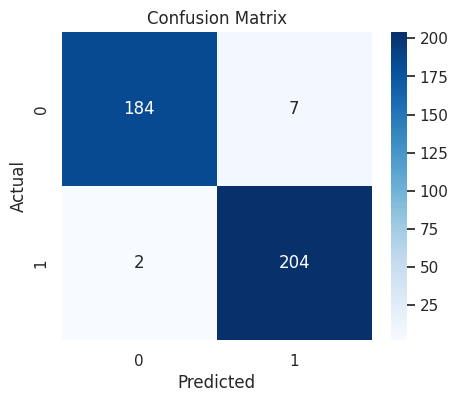

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## menyimpan model

In [ ]:
os.makedirs('../Models', exist_ok=True)
model_path = '../Models/lightgbm_model.pkl'
joblib.dump(model, model_path)
print(f'Model berhasil disimpan di: {model_path}')

Model berhasil disimpan di: ../Models/lightgbm_model.pkl


# evaluasi

# Explainable AI (XAI) Menggunakan SHAP

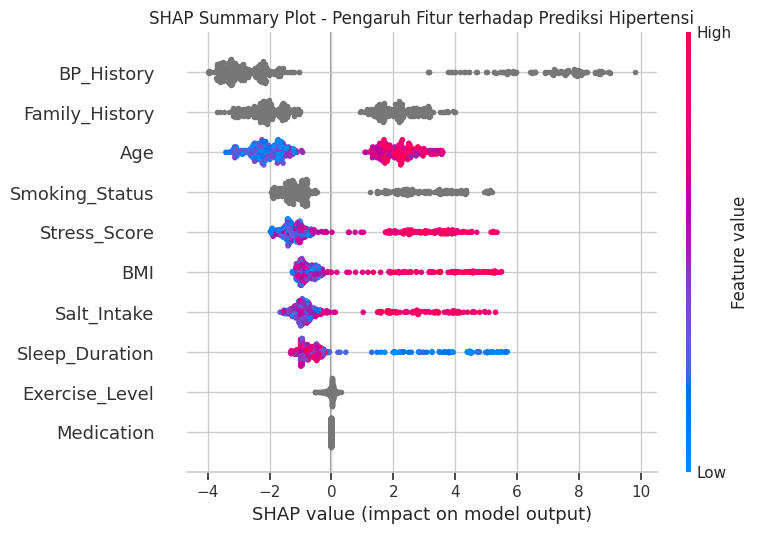

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

plt.figure()
shap.summary_plot(shap_values_plot, X_test, show=False)
plt.title('SHAP Summary Plot - Pengaruh Fitur terhadap Prediksi Hipertensi')
plt.tight_layout()
plt.show()

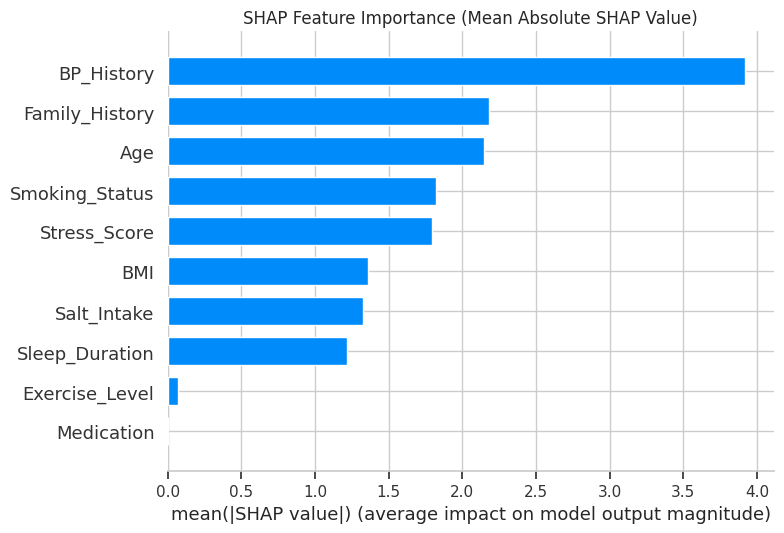

In [ ]:
plt.figure()
shap.summary_plot(shap_values_plot, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean Absolute SHAP Value)')
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

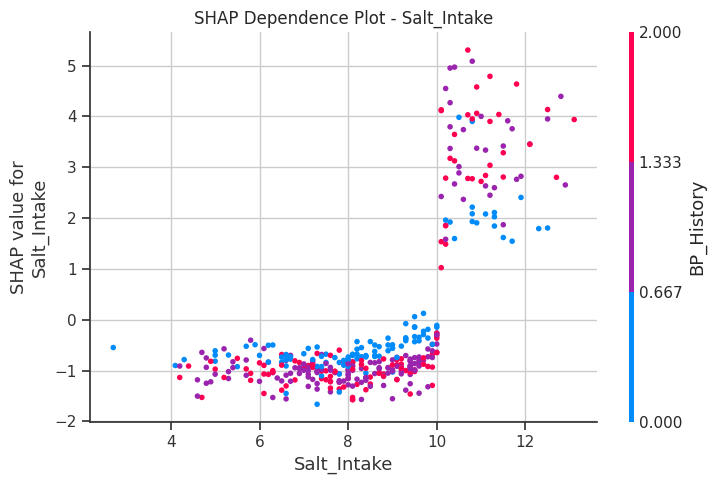

In [ ]:
plt.figure()
shap.dependence_plot('Salt_Intake', shap_values_plot, X_test, show=False)
plt.title('SHAP Dependence Plot - Salt_Intake')
plt.tight_layout()
plt.show()

## WATERFALL

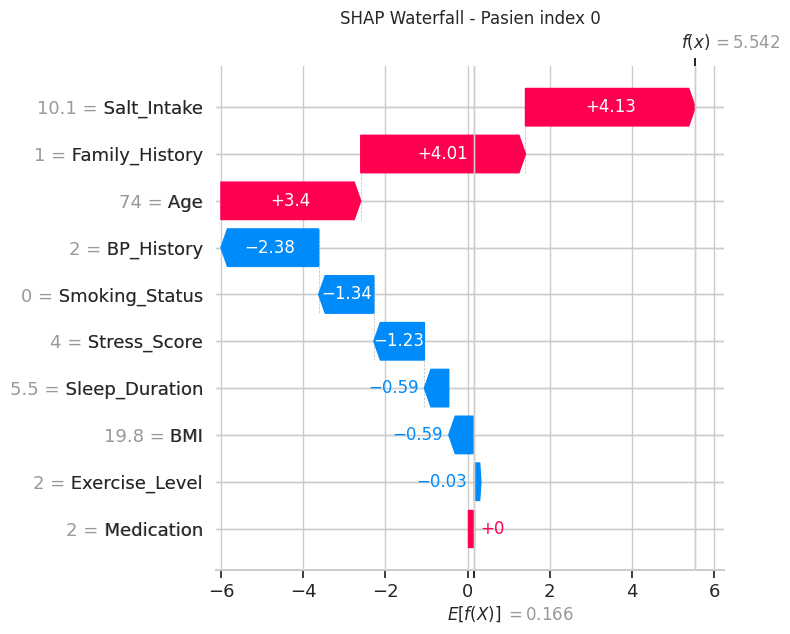

In [ ]:
sample_idx = 0
explainer_exp = shap.Explainer(model)
shap_exp_values = explainer_exp(X_test)

plt.figure()
shap.plots.waterfall(shap_exp_values[sample_idx], show=False)
plt.title(f'SHAP Waterfall - Pasien index {sample_idx}')
plt.tight_layout()
plt.show()

## RANKING FITUR PALING BERPENGARUH

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Abs_SHAP': np.abs(shap_values_plot).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False)

print("=== RANKING FITUR BERDASARKAN SHAP ===")
print(feature_importance)

=== RANKING FITUR BERDASARKAN SHAP ===
          Feature  Mean_Abs_SHAP
3      BP_History       3.919268
7  Family_History       2.183655
0             Age       2.149546
9  Smoking_Status       1.821195
2    Stress_Score       1.794558
5             BMI       1.361261
1     Salt_Intake       1.325747
4  Sleep_Duration       1.213803
8  Exercise_Level       0.069508
6      Medication       0.000000
